In [5]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

print("Librerias cargadas")

Librerias cargadas


In [59]:
import kagglehub
import os
import pandas as pd


path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")
print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, 'Salary_dataset.csv'))
print("Dataset cargado")

Using Colab cache for faster access to the 'salary-dataset-simple-linear-regression' dataset.
Path to dataset files: /kaggle/input/salary-dataset-simple-linear-regression
Dataset cargado


In [61]:
# Muestra las primeras 5 filas con .head()
print("Primeras 5 filas del dataset:")
print(df.head())
print("-" * 50)



Primeras 5 filas del dataset:
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
--------------------------------------------------


In [63]:
# Número de filas, número de columnas con df.shape
filas, columnas = df.shape
print(f"Número de filas: {filas}")
print(f"Número de columnas: {columnas}")
print("-" * 50)



Número de filas: 30
Número de columnas: 3
--------------------------------------------------


In [64]:
# tipos de datos (df.info())
print("Tipos de datos del DataFrame:")
df.info()
print("-" * 50)



Tipos de datos del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
--------------------------------------------------


In [10]:
# valores nulos (df.isnull().sum())
print("❓ Conteo de valores nulos:")
print(df.isnull().sum())
print("-" * 50)



❓ Conteo de valores nulos:
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64
--------------------------------------------------


In [65]:
# Muestra las estadísticas descriptivas con .describe().round(2)
print("Estadísticas descriptivas:")
print(df.describe().round(2))

Estadísticas descriptivas:
       Unnamed: 0  YearsExperience     Salary
count       30.00            30.00      30.00
mean        14.50             5.41   76004.00
std          8.80             2.84   27414.43
min          0.00             1.20   37732.00
25%          7.25             3.30   56721.75
50%         14.50             4.80   65238.00
75%         21.75             7.80  100545.75
max         29.00            10.60  122392.00


In [67]:
# Verificamos que no haya valores nulos (Sección de control)
print(" Verificación de nulos:")
print(df.isnull().sum())
print("-" * 50)

 Verificación de nulos:
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64
--------------------------------------------------


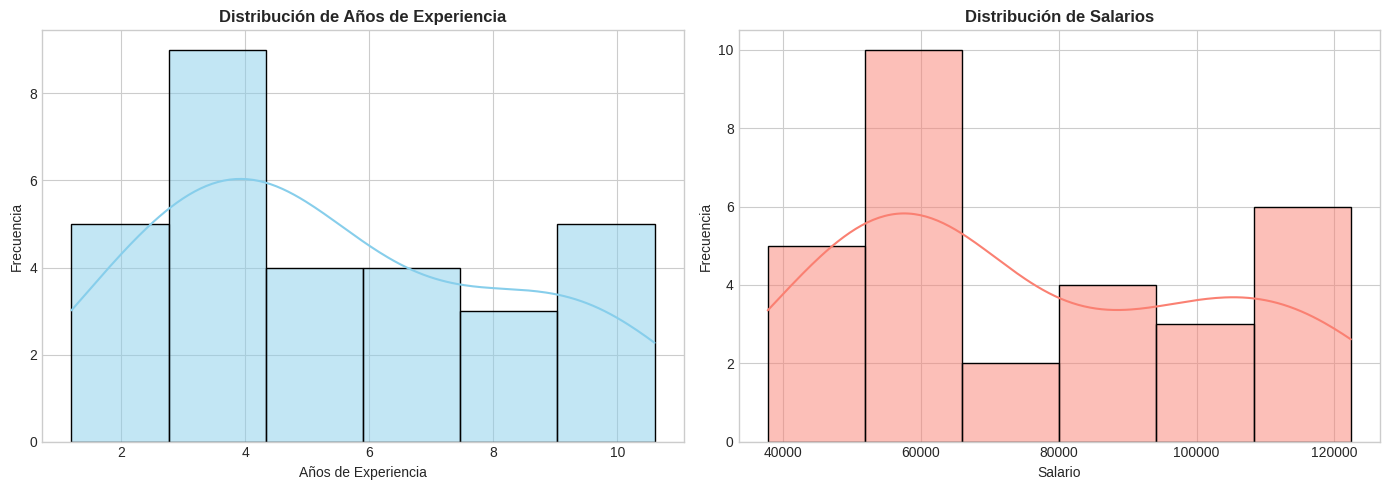

In [68]:
# Crea un subplot con 2 histogramas: uno para YearsExperience y otro para Salary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Años de Experiencia
sns.histplot(df['YearsExperience'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Años de Experiencia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Años de Experiencia')
axes[0].set_ylabel('Frecuencia')


# Histograma de Salario
sns.histplot(df['Salary'], kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Salarios', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Salario')
axes[1].set_ylabel('Frecuencia')


plt.tight_layout()
plt.show()

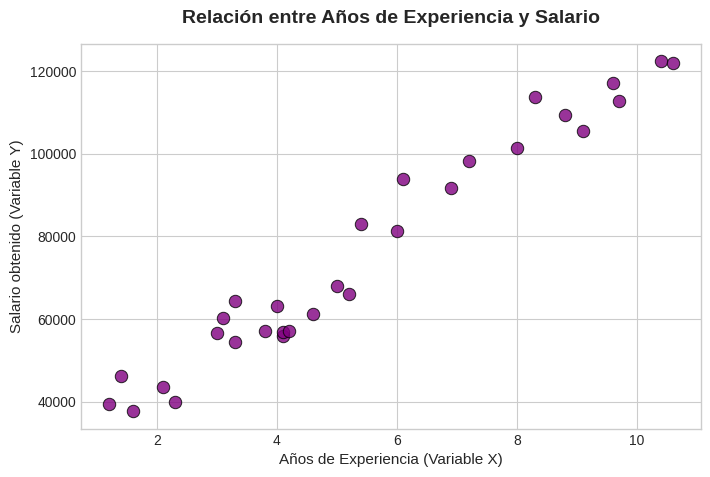

In [21]:
# Crea un scatter plot de YearsExperience (eje X) vs Salary (eje Y)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='YearsExperience', y='Salary', color='purple', s=80, edgecolor='black', alpha=0.8)
plt.title('Relación entre Años de Experiencia y Salario', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Años de Experiencia (Variable X)', fontsize=11)
plt.ylabel('Salario obtenido (Variable Y)', fontsize=11)
plt.show()

In [69]:
# Calcula la correlación de Pearson entre YearsExperience y Salary con .corr()
correlacion = df['YearsExperience'].corr(df['Salary'])

print(f"Correlación de Pearson calculada: {correlacion:.4f}")

Correlación de Pearson calculada: 0.9782


In [71]:
# Interpretación del resultado
print("\n Interpretación:")
if correlacion > 0.95:
    print(f"La correlación es de {correlacion:.4f} (> 0.95), lo cual es EXCELENTE.")
    print("Indica una relación lineal positiva casi perfecta. Esto significa que a medida que aumentan")
    print("los años de experiencia, el salario se incrementa de forma directamente proporcional.")
    print("El dataset es un candidato ideal para ser modelado con una Regresión Lineal Simple.")
else:
    print(f"La correlación es de {correlacion:.4f}. Aunque es alta, no supera el umbral de 0.95.")


 Interpretación:
La correlación es de 0.9782 (> 0.95), lo cual es EXCELENTE.
Indica una relación lineal positiva casi perfecta. Esto significa que a medida que aumentan
los años de experiencia, el salario se incrementa de forma directamente proporcional.
El dataset es un candidato ideal para ser modelado con una Regresión Lineal Simple.


In [77]:
#  X (Matriz de características en 2D) e y (Vector objetivo en 1D)
X = df[['YearsExperience']]  #
y = df['Salary']

# 2. Imprime las formas (shape) de X e y
print("Formas iniciales de los datos:")
print(f"Forma de X (Características): {X.shape}")
print(f"Forma de y (Objetivo):        {y.shape}")
print("-" * 50)

Formas iniciales de los datos:
Forma de X (Características): (30, 1)
Forma de y (Objetivo):        (30,)
--------------------------------------------------


In [74]:
# 3. Usa train_test_split con test_size=0.2 y random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
# 4. Imprime cuántas muestras hay en entrenamiento y prueba
print(" Distribución de las muestras tras la división:")
print(f"Muestras en Entrenamiento (X_train): {X_train.shape[0]} filas")
print(f"Muestras en Prueba (X_test):        {X_test.shape[0]} filas")
print("-" * 50)
print(f"Forma final de X_train: {X_train.shape}")
print(f"Forma final de X_test:  {X_test.shape}")

 Distribución de las muestras tras la división:
Muestras en Entrenamiento (X_train): 24 filas
Muestras en Prueba (X_test):        6 filas
--------------------------------------------------
Forma final de X_train: (24, 1)
Forma final de X_test:  (6, 1)


In [29]:
# Crear e instanciar el modelo
modelo = LinearRegression()

In [79]:
#  Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

LinearRegression()

In [86]:
#  Extraer e imprimir los coeficientes ajustados
beta_0 = modelo.intercept_
beta_1 = modelo.coef_[0]

print(" Coeficientes del modelo obtenidos de forma exitosa:")
print(f"   • Intercepto (β₀): {beta_0:.2f}")
print(f"   • Pendiente  (β₁): {beta_1:.2f}")
print("-" * 60)
print(f" Ecuación matemática del modelo: Salario = {beta_0:.2f} + ({beta_1:.2f} * Experiencia)")
print("-" * 60)


 Coeficientes del modelo obtenidos de forma exitosa:
   • Intercepto (β₀): 24380.20
   • Pendiente  (β₁): 9423.82
------------------------------------------------------------
 Ecuación matemática del modelo: Salario = 24380.20 + (9423.82 * Experiencia)
------------------------------------------------------------


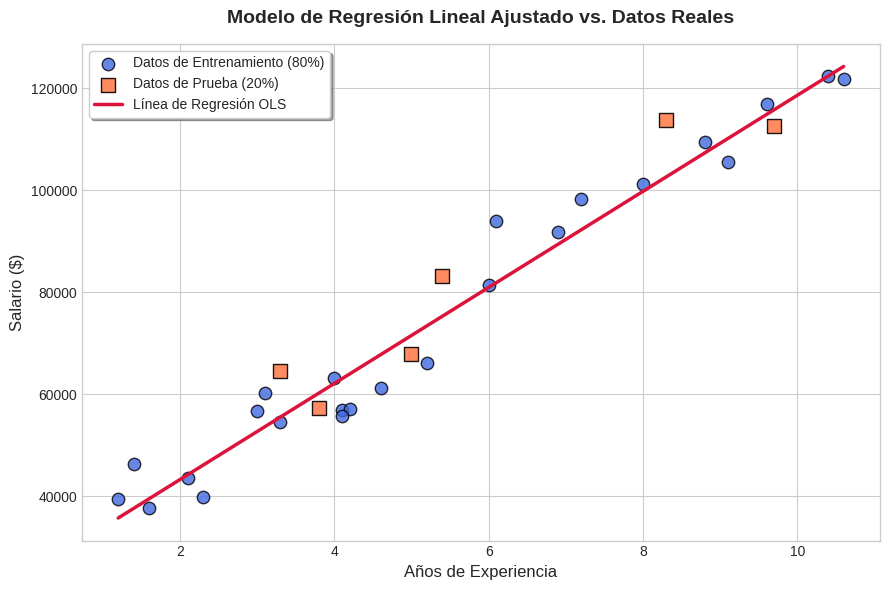

In [94]:
# Generar los datos continuos para la línea
X_linea = np.linspace(df['YearsExperience'].min(), df['YearsExperience'].max(), 100).reshape(-1, 1)
X_linea_df = pd.DataFrame(X_linea, columns=['YearsExperience'])
y_linea = modelo.predict(X_linea_df)

#  Inicializar y trazar el gráfico completo
plt.figure(figsize=(9, 6))

# Graficar puntos de Entrenamiento (Azul)
plt.scatter(X_train, y_train, color='royalblue', s=80, label='Datos de Entrenamiento (80%)', alpha=0.8, edgecolor='black')

# Graficar puntos de Prueba (Coral)
plt.scatter(X_test, y_test, color='coral', s=100, marker='s', label='Datos de Prueba (20%)', alpha=0.9, edgecolor='black')

# Superponer la línea de regresión aprendida por el modelo (Crimson)
plt.plot(X_linea, y_linea, color='crimson', linewidth=2.5, label=f'Línea de Regresión OLS')

# Configuraciones estéticas del gráfico
plt.title('Modelo de Regresión Lineal Ajustado vs. Datos Reales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Años de Experiencia', fontsize=12)
plt.ylabel('Salario ($)', fontsize=12)
plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
plt.tight_layout()

# Mostrar el gráfico en pantalla
plt.show()

In [96]:
#1. Genera predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)
# 2. Crea un DataFrame comparando los resultados reales con las predicciones
df_comparativa = pd.DataFrame({
    'Años_Exp': X_test['YearsExperience'].values,
    'Salario_Real': y_test.values,
    'Salario_Predicho': y_pred,
    'Error': y_test.values - y_pred
})

print("Tabla comparativa de Predicciones vs. Valores Reales (Test):")
print(df_comparativa.round(2))
print("-" * 65)

Tabla comparativa de Predicciones vs. Valores Reales (Test):
   Años_Exp  Salario_Real  Salario_Predicho     Error
0       9.7      112636.0         115791.21  -3155.21
1       5.0       67939.0          71499.28  -3560.28
2       8.3      113813.0         102597.87  11215.13
3       5.4       83089.0          75268.80   7820.20
4       3.3       64446.0          55478.79   8967.21
5       3.8       57190.0          60190.70  -3000.70
-----------------------------------------------------------------


In [98]:
# 3. Calcula e imprime las métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred)

print("Métricas de Evaluación en el Conjunto de Prueba:")
print(f"   • MAE  (Error Absoluto Medio):      ${mae:.2f}  (Esperado < $5,000) {'✅' if mae < 5000 else '⚠️'}")
print(f"   • MSE  (Error Cuadrático Medio):    {mse:.2f}")
print(f"   • RMSE (Raíz Err. Cuadrático Med): ${rmse:.2f}")
print(f"   • R²   (Coef. de Determinación):    {r2_test:.4f}  (Esperado ≥ 0.90)  {'✅' if r2_test >= 0.90 else '⚠️'}")
print("-" * 65)

Métricas de Evaluación en el Conjunto de Prueba:
   • MAE  (Error Absoluto Medio):      $6286.45  (Esperado < $5,000) ⚠️
   • MSE  (Error Cuadrático Medio):    49830096.86
   • RMSE (Raíz Err. Cuadrático Med): $7059.04
   • R²   (Coef. de Determinación):    0.9024  (Esperado ≥ 0.90)  ✅
-----------------------------------------------------------------


In [99]:
# 1. Calcula los residuos
residuos = y_test.values - y_pred

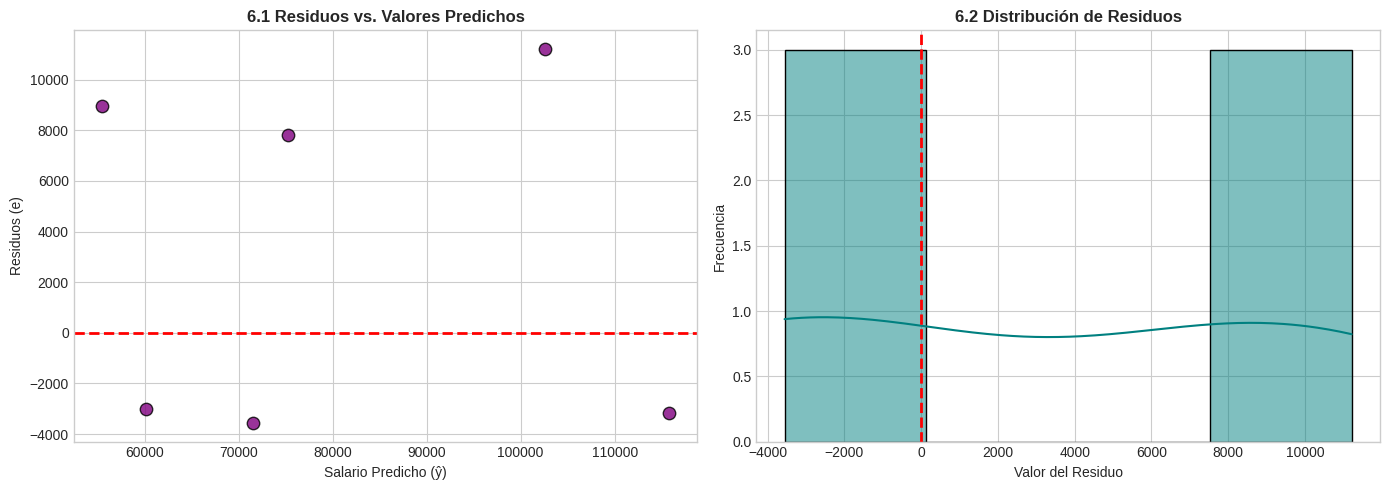

In [101]:
# 2. Crea 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot  Scatter plot de Residuos vs Predicciones
axes[0].scatter(y_pred, residuos, color='purple', s=80, alpha=0.8, edgecolor='black')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('6.1 Residuos vs. Valores Predichos', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Salario Predicho (ŷ)')
axes[0].set_ylabel('Residuos (e)')


sns.histplot(residuos, kde=True, color='teal', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('6.2 Distribución de Residuos', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valor del Residuo')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [102]:
print("🛠️ Diagnóstico del Modelo:")

# 1. Detecta outliers basados en la desviación estándar de los residuos
umbral = 2 * residuos.std()
indices_outliers = np.where(np.abs(residuos) > umbral)[0]

if len(indices_outliers) > 0:
    print(f"   ⚠️ Se detectaron {len(indices_outliers)} posibles outliers con errores grandes:")
    print(df_comparativa.iloc[indices_outliers].round(2))
else:
    print("   ✅ No se detectaron outliers significativos en el conjunto de test (Errores dentro del rango normal).")

🛠️ Diagnóstico del Modelo:
   ✅ No se detectaron outliers significativos en el conjunto de test (Errores dentro del rango normal).


In [103]:
#  Analiza sobreajuste (Overfitting) comparando R² Train vs. Test
r2_train = r2_score(y_train, modelo.predict(X_train))
brecha = r2_train - r2_test

print(f"\n📈 Comparativa de Ajuste (Train vs. Test):")
print(f"   • R² Entrenamiento: {r2_train:.4f}")
print(f"   • R² Prueba:        {r2_test:.4f}")
print(f"   • Diferencia:       {brecha:.4f} " + ("⚠️ (Posible Overfitting)" if brecha > 0.10 else "✅ (Modelo Balanceado)"))


📈 Comparativa de Ajuste (Train vs. Test):
   • R² Entrenamiento: 0.9645
   • R² Prueba:        0.9024
   • Diferencia:       0.0621 ✅ (Modelo Balanceado)


In [104]:
#  Validación Cruzada (Cross-Validation)
from sklearn.model_selection import cross_val_score
# Usamos el dataset completo (X, y) para evaluar la estabilidad global
cv_scores = cross_val_score(modelo, X, y, cv=5, scoring='r2')

print(f"\n➿ Resultados de Validación Cruzada (K-Fold CV = 5):")
print(f"   • R² por Fold:          {cv_scores.round(4)}")
print(f"   • R² Promedio (Mean):   {cv_scores.mean():.4f}")
print(f"   • Desviación Estándar:  {cv_scores.std():.4f}")
print("-" * 65)


➿ Resultados de Validación Cruzada (K-Fold CV = 5):
   • R² por Fold:          [ 0.3596 -1.2442  0.2505  0.297   0.0703]
   • R² Promedio (Mean):   -0.0534
   • Desviación Estándar:  0.6032
-----------------------------------------------------------------


In [105]:
# Crea un DataFrame con nuevos valores de YearsExperience
nuevos_datos = pd.DataFrame({'YearsExperience': [1.5, 5.0, 8.0, 10.0, 12.0]})

In [107]:
# Usa modelo.predict() para obtener los salarios estimados
nuevas_predicciones = modelo.predict(nuevos_datos)

print(" Predicciones de Salario para Nuevos Empleados:")
for exp, sueldo in zip(nuevos_datos['YearsExperience'], nuevas_predicciones):
    print(f"   • Con {exp} años de experiencia, el salario estimado es: ${sueldo:,.2f}")
print("-" * 65)

 Predicciones de Salario para Nuevos Empleados:
   • Con 1.5 años de experiencia, el salario estimado es: $38,515.92
   • Con 5.0 años de experiencia, el salario estimado es: $71,499.28
   • Con 8.0 años de experiencia, el salario estimado es: $99,770.72
   • Con 10.0 años de experiencia, el salario estimado es: $118,618.35
   • Con 12.0 años de experiencia, el salario estimado es: $137,465.99
-----------------------------------------------------------------


In [108]:
print("📋 RESUMEN GENERAL DEL MODELO DE REGRESIÓN")
print("=" * 65)
print(f"📝 Ecuación Ajustada:   Salario = {modelo.intercept_:.2f} + ({modelo.coef_[0]:.2f} × Años)")
print(f"📊 R² (Prueba):         {r2_test:.4f} [{'✅ Excelente' if r2_test >= 0.90 else '⚠️ Requiere Revisión'}]")
print(f"📉 MAE (Prueba):        ${mae:.2f} [{'✅ Dentro del Margen' if mae < 5000 else '⚠️ Desviación Alta'}]")
print(f"📏 RMSE (Prueba):       ${rmse:.2f}")
print(f"➿ R² Promedio (CV):    {cv_scores.mean():.4f} (Estabilidad del modelo en todo el dataset)")
print("=" * 65)

📋 RESUMEN GENERAL DEL MODELO DE REGRESIÓN
📝 Ecuación Ajustada:   Salario = 24380.20 + (9423.82 × Años)
📊 R² (Prueba):         0.9024 [✅ Excelente]
📉 MAE (Prueba):        $6286.45 [⚠️ Desviación Alta]
📏 RMSE (Prueba):       $7059.04
➿ R² Promedio (CV):    -0.0534 (Estabilidad del modelo en todo el dataset)
